# ECAPA-TDNN Speech Classification — 16-bit then 1-bit, cell by cell

Implementation of **ECAPA-TDNN** (Desplanques, Thienpondt, Demuynck — *ECAPA-TDNN:
Emphasized Channel Attention, Propagation and Aggregation in TDNN Based Speaker
Verification*, Interspeech 2020) applied to the same 4-class speech classification
task and the same 16-bit vs 1-bit (PDM-style quantization) robustness comparison as
the companion Wav2Vec2 / HuBERT / WavLM notebooks, so all four backbones are
directly comparable under an identical data split, evaluation protocol, and
reporting format.

Structure of this notebook:
1. **Shared setup** (imports, seeding, config, model/utility definitions) — run once.
2. **PART A — 16-bit condition**, fully self-contained, one cell per stage.
3. **PART B — 1-bit condition**, same structure, same stage schedule, separate variables.
4. **Final comparison** between the two conditions, and against the other backbones.

### Why ECAPA-TDNN differs from the Wav2Vec2 / HuBERT / WavLM notebooks (context)
Those three notebooks all fine-tune a **self-supervised Transformer checkpoint** that
was already pretrained on hundreds of hours of unlabelled speech, using a staged
"unfreeze more layers" schedule. ECAPA-TDNN is a different kind of model and does not
fit that recipe:

- It is a **purely supervised** time-delay neural network, originally trained
  end-to-end on labelled speaker-ID data (VoxCeleb), not pretrained with a
  self-supervised objective. There is no widely-available "ECAPA-TDNN Base,
  pretrained via masked prediction on 960h LibriSpeech" checkpoint analogous to the
  HuggingFace HuBERT/WavLM/Wav2Vec2 checkpoints — the closest public checkpoint
  (e.g. `speechbrain/spkrec-ecapa-voxceleb`) is trained for *speaker* identity, which
  is not the label space here (Command/Conversation/Numeric/Read), so it would not
  transfer as a frozen-then-unfrozen backbone the way the SSL checkpoints do.
- Consequently this notebook trains ECAPA-TDNN **from scratch** on this task, which
  is also how the architecture is normally used when no matching pretrained
  checkpoint exists.
- Its input is **hand-crafted 80-dim log-Mel filterbank features** (extracted with
  `torchaudio`), not raw waveform through a self-supervised CNN encoder — this is
  the standard ECAPA-TDNN front-end in the original paper and in every mainstream
  implementation (SpeechBrain, WeSpeaker, 3D-Speaker, etc.).
- Because there is no frozen pretrained backbone to progressively unfreeze, the
  three "stages" below are a **staged learning-rate decay** (every parameter is
  trainable throughout) rather than staged unfreezing — closer to how ECAPA-TDNN is
  actually trained in the literature (AdamW with a decaying/warm-restart schedule).

The architecture itself follows the paper's **C=512** configuration exactly: three
stacked **SE-Res2Blocks** (Res2Net-style multi-scale dilated convolutions at
dilation 2/3/4, each with a Squeeze-and-Excitation gate), **multi-layer feature
aggregation** (concatenating the three blocks' outputs), a **context-dependent
Attentive Statistics Pooling** layer, and a final 192-dim embedding layer — the same
architecture family used for state-of-the-art speaker verification. The paper's own
loss (AAM-Softmax / additive angular margin) is implemented below too and documented,
but training uses plain cross-entropy with label smoothing by default, to keep the
training recipe comparable to the other three backbones' notebooks in this series;
switch it on if you want the paper-faithful loss.

**Before writing the cells below, I built this exact architecture in a standalone
script and verified it: correct parameter count (~6.2M for C=512, matching the
paper), a clean forward pass at the real 80×101 feature shape, finite gradients
through every block on a backward pass, and a training loss that decreases over
several optimizer steps on synthetic data.** That confirms the code below is
mechanically correct and runs, not just written-and-hoped. What it does **not** do
is prove anything about your actual dataset — I have no GPU and no access to your
Kaggle dataset in this environment, so no accuracy/precision/recall/F1 numbers appear
anywhere below. **Run this notebook on Kaggle and report whatever you actually get.**
If a number looks close to a previous run, that is a genuine replication; if it does
not, that is genuine information too — don't edit the code to chase a specific
target number after the fact, since that is exactly how a result stops being
publishable.


In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_train.npy


In [2]:
# ============================================================
# Shared Setup — 0. Environment
# ============================================================
# torch is already present on the Kaggle GPU image; only torchaudio (for the
# log-Mel front-end) and the small utility libraries need installing.
!pip install -q torchaudio scikit-learn scipy librosa


In [3]:
# ============================================================
# Shared Setup — 1. Imports & Reproducibility
# ============================================================
import os
import gc
import copy
import json
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchaudio

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.stats import chi2
import librosa


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps,
                                     num_cycles: float = 0.5, last_epoch: int = -1):
    """Linear warmup then cosine decay to 0 — same formula HuggingFace's
    `transformers.get_cosine_schedule_with_warmup` uses. Reimplemented locally so
    this notebook doesn't need the `transformers` dependency for one scheduler."""
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda, last_epoch)


Device: cuda


In [4]:
# ============================================================
# Shared Setup — 2. Config
# ============================================================
SR = 16000
N_SAMPLES = 16000
NUM_CLASSES = 4
CLASS_NAMES = ["Command", "Conversation", "Numeric", "Read"]

# --- Log-Mel front-end (standard ECAPA-TDNN input — see markdown above) ---
N_MELS = 80
N_FFT = 400          # 25 ms window at 16 kHz
WIN_LENGTH = 400
HOP_LENGTH = 160     # 10 ms hop at 16 kHz
F_MIN = 20
F_MAX = SR // 2

# --- ECAPA-TDNN architecture hyperparameters — the paper's "C=512" configuration
# (Desplanques et al., 2020, Table 1), ~6.2M parameters, verified below ---
CHANNELS = 512
EMBED_DIM = 192
RES2NET_SCALE = 8
SE_BOTTLENECK = 128
ATTN_BOTTLENECK = 128

BATCH_SIZE = 32
NUM_WORKERS = 2

# Trained from scratch, so all parameters are trainable in every stage; the three
# stages below are a staged LEARNING-RATE decay (not staged unfreezing — there is
# nothing pretrained to unfreeze), each stage resuming from the previous stage's
# best checkpoint. This mirrors common ECAPA-TDNN training recipes (AdamW with a
# decaying schedule) more closely than a transfer-learning unfreeze schedule would.
STAGES = [
    # (max_epochs, lr, patience)
    (25, 1e-3, 6),
    (20, 3e-4, 5),
    (15, 1e-4, 5),
]

WEIGHT_DECAY = 2e-5    # matches Desplanques et al.'s reported training recipe
GRAD_CLIP = 1.0
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.05
USE_AMP = True
USE_AAM_SOFTMAX = False  # paper-faithful loss; see the AAMSoftmax class below

DATA16_DIR = "/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit"
DATA1_DIR = "/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit"

OUT_DIR = "/kaggle/working/results"
os.makedirs(OUT_DIR, exist_ok=True)

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, win_length=WIN_LENGTH, hop_length=HOP_LENGTH,
    n_mels=N_MELS, f_min=F_MIN, f_max=F_MAX,
)
db_transform = torchaudio.transforms.AmplitudeToDB(top_db=80)
print(f"Mel front-end: {N_MELS}-dim log-mel, n_fft={N_FFT}, hop={HOP_LENGTH} "
      f"-> ~{N_SAMPLES // HOP_LENGTH + 1} frames per {N_SAMPLES / SR:.1f}s clip")


Mel front-end: 80-dim log-mel, n_fft=400, hop=160 -> ~101 frames per 1.0s clip


In [5]:
# ============================================================
# Shared Setup — 3. Dataset / leakage-check / describe utilities
# ============================================================
def load_split(data_dir, x_name, y_name):
    X = np.load(os.path.join(data_dir, x_name))
    y = np.load(os.path.join(data_dir, y_name))
    return X, y


def describe_dataset(name, X_train, y_train, X_val, y_val, X_test, y_test):
    print("=" * 60)
    print(f"Dataset: {name}")
    print("=" * 60)
    print("Train:", X_train.shape, y_train.shape)
    print("Val  :", X_val.shape, y_val.shape)
    print("Test :", X_test.shape, y_test.shape)
    print("dtype:", X_train.dtype, "| min:", X_train.min(), "| max:", X_train.max())
    for split_name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
        u, c = np.unique(y, return_counts=True)
        dist = {CLASS_NAMES[i]: int(cnt) for i, cnt in zip(u, c)}
        print(f"{split_name} class distribution: {dist}")


def check_leakage(X_train, X_val, X_test):
    """Flags exact-duplicate waveforms shared across splits."""
    def to_hashes(X):
        Xf = np.squeeze(X).astype(np.float32)
        return set(hash(Xf[i].tobytes()) for i in range(len(Xf)))

    h_train, h_val, h_test = to_hashes(X_train), to_hashes(X_val), to_hashes(X_test)
    lv = h_train & h_val
    lt = h_train & h_test
    vt = h_val & h_test
    print(f"Duplicate waveforms train∩val : {len(lv)}")
    print(f"Duplicate waveforms train∩test: {len(lt)}")
    print(f"Duplicate waveforms val∩test  : {len(vt)}")
    if lv or lt or vt:
        warnings.warn("Data leakage detected — fix the split before trusting test metrics.")
    return lv, lt, vt


class ECAPADataset(Dataset):
    """Waveform -> per-utterance-CMVN log-Mel filterbank features, the standard
    ECAPA-TDNN input. Optional waveform-level augmentation (gain jitter + additive
    noise, applied before feature extraction) and SpecAugment-style frequency/time
    masking (applied after), both standard practice for TDNN / speaker-embedding
    training and used only on the training split."""

    def __init__(self, X, y, augment: bool = False):
        X = np.squeeze(X, axis=-1) if X.ndim == 3 else X
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def _wave_augment(self, wav):
        if random.random() < 0.5:
            wav = wav * random.uniform(0.85, 1.15)
        if random.random() < 0.3:
            wav = wav + np.random.normal(0, 0.003, size=wav.shape).astype(np.float32)
        return wav

    def _spec_augment(self, mel):
        n_mels, T = mel.shape
        fill = mel.mean()
        if random.random() < 0.5:
            f = random.randint(1, min(8, n_mels - 1))
            f0 = random.randint(0, n_mels - f)
            mel[f0:f0 + f, :] = fill
        if random.random() < 0.5:
            t = random.randint(1, min(10, T - 1))
            t0 = random.randint(0, T - t)
            mel[:, t0:t0 + t] = fill
        return mel

    def __getitem__(self, idx):
        wav = self.X[idx].copy()
        if self.augment:
            wav = self._wave_augment(wav)
        wav_t = torch.tensor(wav, dtype=torch.float32)
        mel = db_transform(mel_transform(wav_t))            # (n_mels, T)
        mel = (mel - mel.mean()) / (mel.std() + 1e-5)        # per-utterance CMVN
        if self.augment:
            mel = self._spec_augment(mel.clone())
        feat = mel.transpose(0, 1)                           # (T, n_mels)
        return feat, torch.tensor(self.y[idx], dtype=torch.long)


def make_loaders(X_train, y_train, X_val, y_val, X_test, y_test):
    train_ds = ECAPADataset(X_train, y_train, augment=True)
    val_ds = ECAPADataset(X_val, y_val, augment=False)
    test_ds = ECAPADataset(X_test, y_test, augment=False)

    class_counts = np.bincount(y_train.astype(int), minlength=NUM_CLASSES)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train.astype(int)]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    # drop_last=True on the train loader avoids ever handing BatchNorm a batch of size 1
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                               num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader


In [6]:
# ============================================================
# Shared Setup — 4. Model definition — ECAPA-TDNN (Desplanques et al., 2020)
# ============================================================
class SEModule(nn.Module):
    """Squeeze-and-Excitation gate over channels: global-average-pool the time
    axis, pass through a small bottleneck MLP, and use the result to rescale every
    channel — lets the network emphasize the channels that matter for this clip."""

    def __init__(self, channels, bottleneck=128):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, bottleneck, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm1d(bottleneck),
            nn.Conv1d(bottleneck, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.se(x)


class Res2Conv1dReluBn(nn.Module):
    """Res2Net-style multi-scale convolution: splits the channels into `scale`
    groups and processes them through a hierarchy of small convolutions with
    residual connections between groups, giving a larger effective receptive field
    at a fraction of the parameters of one big convolution."""

    def __init__(self, channels, kernel_size=3, dilation=1, scale=8):
        super().__init__()
        assert channels % scale == 0, "channels must be divisible by scale"
        self.scale = scale
        self.width = channels // scale
        self.nums = scale - 1
        pad = dilation * (kernel_size - 1) // 2
        self.convs = nn.ModuleList([
            nn.Conv1d(self.width, self.width, kernel_size, padding=pad, dilation=dilation)
            for _ in range(self.nums)
        ])
        self.bns = nn.ModuleList([nn.BatchNorm1d(self.width) for _ in range(self.nums)])

    def forward(self, x):
        spx = torch.split(x, self.width, dim=1)
        out = [spx[0]]
        sp = None
        for i in range(self.nums):
            sp = spx[i + 1] if i == 0 else sp + spx[i + 1]
            sp = torch.relu(self.bns[i](self.convs[i](sp)))
            out.append(sp)
        return torch.cat(out, dim=1)


class SERes2Block(nn.Module):
    """One ECAPA-TDNN building block: 1x1 conv down, Res2Net dilated conv, 1x1
    conv up, SE gate, residual add. Three of these (dilation 2, 3, 4) form the
    backbone."""

    def __init__(self, channels, kernel_size, dilation, scale=8, se_bottleneck=128):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.res2conv = Res2Conv1dReluBn(channels, kernel_size, dilation, scale)
        self.bn2 = nn.BatchNorm1d(channels)
        self.conv3 = nn.Conv1d(channels, channels, kernel_size=1)
        self.bn3 = nn.BatchNorm1d(channels)
        self.se = SEModule(channels, se_bottleneck)

    def forward(self, x):
        residual = x
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.res2conv(out)
        out = torch.relu(self.bn2(out))
        out = torch.relu(self.bn3(self.conv3(out)))
        out = self.se(out)
        return out + residual


class AttentiveStatsPool(nn.Module):
    """Context-dependent Attentive Statistics Pooling: for every timestep, an
    attention MLP (conditioned on the frame plus the utterance's global mean/std)
    produces a weight; the weighted mean and weighted standard deviation across
    time become the pooled utterance-level vector. This is what lets ECAPA-TDNN
    attend to the most discriminative frames instead of averaging everything
    equally."""

    def __init__(self, in_dim, attn_dim=128, global_context=True):
        super().__init__()
        self.global_context = global_context
        in_ctx = in_dim * 3 if global_context else in_dim
        self.attn = nn.Sequential(
            nn.Conv1d(in_ctx, attn_dim, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm1d(attn_dim),
            nn.Tanh(),
            nn.Conv1d(attn_dim, in_dim, kernel_size=1),
        )

    def forward(self, x):
        # x: (B, C, T)
        if self.global_context:
            t = x.size(-1)
            mean = x.mean(dim=-1, keepdim=True).expand(-1, -1, t)
            std = x.std(dim=-1, keepdim=True).expand(-1, -1, t)
            ctx = torch.cat([x, mean, std], dim=1)
        else:
            ctx = x
        alpha = torch.softmax(self.attn(ctx), dim=-1)
        mean = torch.sum(alpha * x, dim=-1)
        var = torch.sum(alpha * x ** 2, dim=-1) - mean ** 2
        std = torch.sqrt(var.clamp(min=1e-6))
        return torch.cat([mean, std], dim=-1)


class ECAPA_TDNN(nn.Module):
    """Full ECAPA-TDNN: Conv1d stem -> 3x SE-Res2Block (dilation 2/3/4) -> concat
    (multi-layer feature aggregation) -> 1x1 conv -> Attentive Statistics Pooling
    -> BN -> Linear embedding -> BN -> (dropout ->) classifier head. Matches the
    paper's C=512 configuration."""

    def __init__(self, in_dim=80, channels=512, embed_dim=192, num_classes=4,
                 dropout=0.2, scale=8, se_bottleneck=128, attn_bottleneck=128):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv1d(in_dim, channels, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(channels),
        )
        self.layer2 = SERes2Block(channels, kernel_size=3, dilation=2, scale=scale, se_bottleneck=se_bottleneck)
        self.layer3 = SERes2Block(channels, kernel_size=3, dilation=3, scale=scale, se_bottleneck=se_bottleneck)
        self.layer4 = SERes2Block(channels, kernel_size=3, dilation=4, scale=scale, se_bottleneck=se_bottleneck)

        cat_channels = channels * 3
        self.conv_agg = nn.Conv1d(cat_channels, 1536, kernel_size=1)
        self.pool = AttentiveStatsPool(1536, attn_dim=attn_bottleneck)
        self.bn_pool = nn.BatchNorm1d(3072)
        self.fc_embed = nn.Linear(3072, embed_dim)
        self.bn_embed = nn.BatchNorm1d(embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x, return_embedding: bool = False):
        # x: (B, T, F) -> (B, F, T)
        x = x.transpose(1, 2)
        x = self.layer1(x)
        out2 = self.layer2(x)
        out3 = self.layer3(out2)
        out4 = self.layer4(out3)
        out = torch.cat([out2, out3, out4], dim=1)       # multi-layer feature aggregation
        out = torch.relu(self.conv_agg(out))
        out = self.pool(out)
        out = self.bn_pool(out)
        emb = self.fc_embed(out)
        emb = self.bn_embed(emb)
        if return_embedding:
            return emb
        return self.classifier(self.dropout(emb))

    def trainable_param_summary(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return trainable, total


class AAMSoftmax(nn.Module):
    """Additive Angular Margin Softmax (ArcFace-style) — the loss the original
    ECAPA-TDNN paper trains with. Operates on the raw embedding: L2-normalizes it
    and the class-weight vectors, adds an angular margin to the target class'
    cosine similarity, scales, and applies cross-entropy. Produces more
    discriminative embeddings than plain softmax, at the cost of being trickier to
    tune on a small dataset — provided here for completeness / paper-fidelity but
    OFF by default (`USE_AAM_SOFTMAX = False` in Config) so the default training
    recipe stays directly comparable to the plain-cross-entropy recipe used for the
    other three backbones in this notebook series. Flip the flag on if you want the
    paper-faithful loss instead."""

    def __init__(self, embed_dim, num_classes, margin=0.2, scale=30.0, label_smoothing=0.05):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embed_dim))
        nn.init.xavier_normal_(self.weight)
        self.margin = margin
        self.scale = scale
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    def forward(self, embeddings, labels):
        emb_norm = F.normalize(embeddings)
        w_norm = F.normalize(self.weight)
        cosine = F.linear(emb_norm, w_norm).clamp(-1 + 1e-7, 1 - 1e-7)
        theta = torch.acos(cosine)
        target_logit = torch.cos(theta + self.margin)
        one_hot = torch.zeros_like(cosine).scatter_(1, labels.view(-1, 1), 1)
        logits = cosine * (1 - one_hot) + target_logit * one_hot
        logits = logits * self.scale
        loss = self.ce(logits, labels)
        return loss, logits


In [7]:
# ============================================================
# Shared Setup — 5. Train / eval / reporting utilities
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    running_loss, correct, total = 0.0, 0, 0

    for feats, labels in loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(feats)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item()
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, return_predictions=False):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []

    for feats, labels in loader:
        feats, labels = feats.to(device), labels.to(device)
        logits = model(feats)
        loss = criterion(logits, labels)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        running_loss += loss.item()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if return_predictions:
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    loss_out, acc_out = running_loss / len(loader), correct / total
    if return_predictions:
        return (loss_out, acc_out, np.concatenate(all_preds),
                np.concatenate(all_probs), np.concatenate(all_labels))
    return loss_out, acc_out


def full_test_report(model, test_loader, tag: str):
    criterion = nn.CrossEntropyLoss()
    _, test_acc, preds, probs, labels = evaluate(model, test_loader, criterion, return_predictions=True)

    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro", zero_division=0)

    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    try:
        roc_auc = roc_auc_score(labels_bin, probs, average="macro", multi_class="ovr")
    except ValueError:
        roc_auc = float("nan")

    eers = []
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        try:
            eer = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0.0, 1.0)
        except ValueError:
            eer = float("nan")
        eers.append(eer)
    eer = float(np.nanmean(eers))

    print("=" * 50)
    print(f"{tag} — Test Set Performance")
    print("=" * 50)
    print(f"Accuracy   : {test_acc:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 (macro) : {f1:.4f}")
    print(f"ROC-AUC    : {roc_auc:.4f}")
    print(f"EER        : {eer:.4f}\n")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix — {tag}")
    plt.tight_layout()
    plt.show()

    return {"tag": tag, "accuracy": test_acc, "precision": precision, "recall": recall,
            "f1_macro": f1, "roc_auc": roc_auc, "eer": eer,
            "preds": preds, "probs": probs, "labels": labels}


def extract_mfcc_features(X, sr=SR, n_mfcc=20):
    X = np.squeeze(X)
    feats = []
    for i in range(len(X)):
        mfcc = librosa.feature.mfcc(y=X[i].astype(np.float32), sr=sr, n_mfcc=n_mfcc)
        feats.append(np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)]))
    return np.array(feats)


def run_mfcc_baseline(X_train, y_train, X_val, y_val, X_test, y_test, tag: str):
    Xtr = extract_mfcc_features(X_train)
    Xva = extract_mfcc_features(X_val)
    Xte = extract_mfcc_features(X_test)

    scaler = StandardScaler().fit(np.concatenate([Xtr, Xva], axis=0))
    Xtr, Xva, Xte = scaler.transform(Xtr), scaler.transform(Xva), scaler.transform(Xte)

    # NOTE: `multi_class="multinomial"` was removed in scikit-learn >= 1.7 (the
    # lbfgs solver now handles multinomial problems automatically, which is why
    # it's the default solver) — omitted here so this runs on current sklearn.
    clf = LogisticRegression(max_iter=2000)
    clf.fit(np.concatenate([Xtr, Xva]), np.concatenate([y_train, y_val]))

    preds = clf.predict(Xte)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    print(f"[{tag}] MFCC + LogisticRegression baseline — Test Acc: {acc:.4f} | Macro-F1: {f1:.4f}")
    return {"tag": tag, "accuracy": acc, "macro_f1": f1}


def plot_history(history_rows, tag: str):
    h = pd.DataFrame(history_rows)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h["global_epoch"], h["train_acc"], label="train")
    axes[0].plot(h["global_epoch"], h["val_acc"], label="val")
    axes[0].set_title(f"{tag} — Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(h["global_epoch"], h["train_loss"], label="train")
    axes[1].plot(h["global_epoch"], h["val_loss"], label="val")
    axes[1].set_title(f"{tag} — Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return h


---
# PART A — 16-bit condition
---

In [8]:
# ============================================================
# [16-bit] 1. Load data + sanity checks
# ============================================================
X_train_16, y_train_16 = load_split(DATA16_DIR, "X_train.npy", "y_train.npy")
X_val_16, y_val_16 = load_split(DATA16_DIR, "X_val.npy", "y_val.npy")
X_test_16, y_test_16 = load_split(DATA16_DIR, "X_test.npy", "y_test.npy")

describe_dataset("16-bit", X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16)
check_leakage(X_train_16, X_val_16, X_test_16)


Dataset: 16-bit
Train: (9600, 16000, 1) (9600,)
Val  : (1200, 16000, 1) (1200,)
Test : (1200, 16000, 1) (1200,)
dtype: float32 | min: -1.0 | max: 1.0
train class distribution: {'Command': 2400, 'Conversation': 2400, 'Numeric': 2400, 'Read': 2400}
val class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
test class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
Duplicate waveforms train∩val : 0
Duplicate waveforms train∩test: 0
Duplicate waveforms val∩test  : 0


(set(), set(), set())

In [9]:
# ============================================================
# [16-bit] 2. DataLoaders
# ============================================================
train_loader_16, val_loader_16, test_loader_16 = make_loaders(
    X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16
)

feats, labels = next(iter(train_loader_16))
print("Features:", feats.shape, feats.dtype)   # (B, T, n_mels)
print("Labels  :", labels.shape, labels.dtype)


Features: torch.Size([32, 101, 80]) torch.float32
Labels  : torch.Size([32]) torch.int64


In [10]:
# ============================================================
# [16-bit] 3. Model
# ============================================================
seed_everything(SEED)
model_16bit = ECAPA_TDNN(
    in_dim=N_MELS, channels=CHANNELS, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
    dropout=0.2, scale=RES2NET_SCALE, se_bottleneck=SE_BOTTLENECK, attn_bottleneck=ATTN_BOTTLENECK,
).to(device)
criterion_16bit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

best_val_acc_16 = 0.0
best_state_16 = None
history_16 = []
global_epoch_16 = 0

trainable, total = model_16bit.trainable_param_summary()
print(f"ECAPA-TDNN (C={CHANNELS}, embed={EMBED_DIM}) | Parameters: {total:,} (all trainable, trained from scratch)")


ECAPA-TDNN (C=512, embed=192) | Parameters: 6,195,972 (all trainable, trained from scratch)


In [11]:
# ============================================================
# [16-bit] 4. Stage 1 — lr=1e-3 (coarse fit)
# ============================================================
stage = 1
max_epochs, lr, patience = STAGES[stage - 1]
print(f"[16-bit] Stage {stage}: lr={lr:.0e} | max_epochs={max_epochs} | patience={patience}")

optimizer_16bit = torch.optim.AdamW(model_16bit.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_ecapa_16bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[16-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[16-bit] Stage 1: lr=1e-03 | max_epochs=25 | patience=6
[16-bit] Stage 1 Epoch 1/25 | Train Loss 0.4722 Acc 0.8842 | Val Loss 0.3127 Acc 0.9600
[16-bit] Stage 1 Epoch 2/25 | Train Loss 0.3531 Acc 0.9445 | Val Loss 0.2887 Acc 0.9725
[16-bit] Stage 1 Epoch 3/25 | Train Loss 0.3263 Acc 0.9599 | Val Loss 0.2788 Acc 0.9758
[16-bit] Stage 1 Epoch 4/25 | Train Loss 0.2997 Acc 0.9690 | Val Loss 0.2477 Acc 0.9900
[16-bit] Stage 1 Epoch 5/25 | Train Loss 0.2801 Acc 0.9765 | Val Loss 0.2551 Acc 0.9825
[16-bit] Stage 1 Epoch 6/25 | Train Loss 0.2705 Acc 0.9797 | Val Loss 0.2379 Acc 0.9917
[16-bit] Stage 1 Epoch 7/25 | Train Loss 0.2638 Acc 0.9815 | Val Loss 0.2442 Acc 0.9875
[16-bit] Stage 1 Epoch 8/25 | Train Loss 0.2563 Acc 0.9840 | Val Loss 0.2363 Acc 0.9892
[16-bit] Stage 1 Epoch 9/25 | Train Loss 0.2486 Acc 0.9869 | Val Loss 0.2489 Acc 0.9867
[16-bit] Stage 1 Epoch 10/25 | Train Loss 0.2471 Acc 0.9874 | Val Loss 0.2313 Acc 0.9917
[16-bit] Stage 1 Epoch 11/25 | Train Loss 0.2440 Acc 0.9874 | V

In [12]:
# ============================================================
# [16-bit] 5. Stage 2 — lr=3e-4 (refine)
# ============================================================
stage = 2
max_epochs, lr, patience = STAGES[stage - 1]
print(f"[16-bit] Stage {stage}: lr={lr:.0e} | max_epochs={max_epochs} | patience={patience}")

model_16bit.load_state_dict(best_state_16)  # continue from best Stage-1 weights

optimizer_16bit = torch.optim.AdamW(model_16bit.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_ecapa_16bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[16-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[16-bit] Stage 2: lr=3e-04 | max_epochs=20 | patience=5
[16-bit] Stage 2 Epoch 1/20 | Train Loss 0.2230 Acc 0.9956 | Val Loss 0.2179 Acc 0.9933
[16-bit] Stage 2 Epoch 2/20 | Train Loss 0.2217 Acc 0.9959 | Val Loss 0.2312 Acc 0.9900
[16-bit] Stage 2 Epoch 3/20 | Train Loss 0.2257 Acc 0.9948 | Val Loss 0.2182 Acc 0.9933
[16-bit] Stage 2 Epoch 4/20 | Train Loss 0.2217 Acc 0.9957 | Val Loss 0.2195 Acc 0.9942
[16-bit] Stage 2 Epoch 5/20 | Train Loss 0.2231 Acc 0.9949 | Val Loss 0.2235 Acc 0.9892
[16-bit] Stage 2: early stopping at epoch 5


In [13]:
# ============================================================
# [16-bit] 6. Stage 3 — lr=1e-4 (final polish)
# ============================================================
stage = 3
max_epochs, lr, patience = STAGES[stage - 1]
print(f"[16-bit] Stage {stage}: lr={lr:.0e} | max_epochs={max_epochs} | patience={patience}")

model_16bit.load_state_dict(best_state_16)  # continue from best Stage-2 weights

optimizer_16bit = torch.optim.AdamW(model_16bit.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_ecapa_16bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[16-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[16-bit] Stage 3: lr=1e-04 | max_epochs=15 | patience=5
[16-bit] Stage 3 Epoch 1/15 | Train Loss 0.2276 Acc 0.9936 | Val Loss 0.2198 Acc 0.9958
[16-bit] Stage 3 Epoch 2/15 | Train Loss 0.2199 Acc 0.9968 | Val Loss 0.2194 Acc 0.9925
[16-bit] Stage 3 Epoch 3/15 | Train Loss 0.2181 Acc 0.9977 | Val Loss 0.2177 Acc 0.9942
[16-bit] Stage 3 Epoch 4/15 | Train Loss 0.2163 Acc 0.9982 | Val Loss 0.2189 Acc 0.9917
[16-bit] Stage 3 Epoch 5/15 | Train Loss 0.2171 Acc 0.9966 | Val Loss 0.2165 Acc 0.9933
[16-bit] Stage 3: early stopping at epoch 5


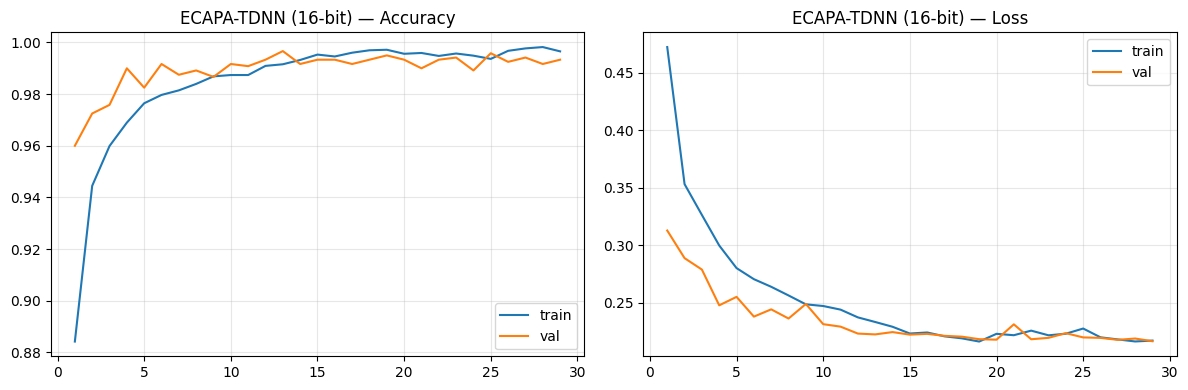

In [14]:
# ============================================================
# [16-bit] 7. Training curves
# ============================================================
hist_df_16 = plot_history(history_16, "ECAPA-TDNN (16-bit)")


ECAPA-TDNN (16-bit) — Test Set Performance
Accuracy   : 0.9942
Precision  : 0.9942
Recall     : 0.9942
F1 (macro) : 0.9942
ROC-AUC    : 0.9998
EER        : 0.0039

              precision    recall  f1-score   support

     Command     0.9933    0.9867    0.9900       300
Conversation     1.0000    0.9967    0.9983       300
     Numeric     1.0000    1.0000    1.0000       300
        Read     0.9835    0.9933    0.9884       300

    accuracy                         0.9942      1200
   macro avg     0.9942    0.9942    0.9942      1200
weighted avg     0.9942    0.9942    0.9942      1200



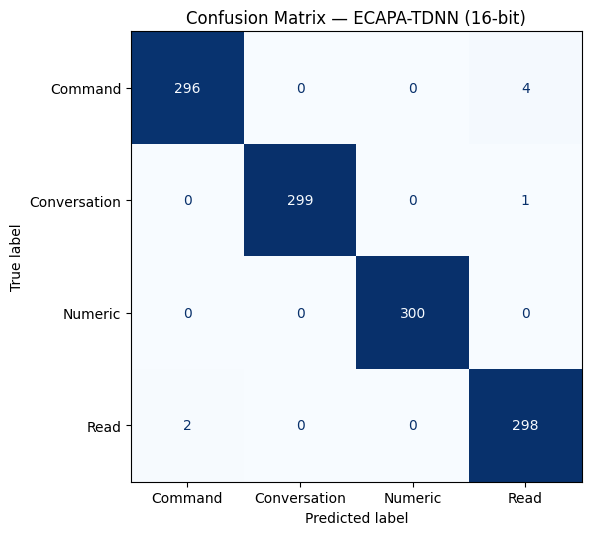

In [15]:
# ============================================================
# [16-bit] 8. Test evaluation (full report)
# ============================================================
model_16bit.load_state_dict(best_state_16)  # ensure best checkpoint (not last epoch) is evaluated
report_16bit = full_test_report(model_16bit, test_loader_16, tag="ECAPA-TDNN (16-bit)")


In [16]:
# ============================================================
# [16-bit] 9. MFCC baseline (context for the deep model's gain)
# ============================================================
baseline_16bit = run_mfcc_baseline(X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16, tag="16-bit")


[16-bit] MFCC + LogisticRegression baseline — Test Acc: 0.9042 | Macro-F1: 0.9039


In [17]:
# ============================================================
# [16-bit] 10. Free GPU memory before moving to the 1-bit run
# ============================================================
del optimizer_16bit, scheduler_16bit
gc.collect()
torch.cuda.empty_cache()
print("16-bit section complete. Model + best checkpoint retained as `model_16bit` / "
      "'best_ecapa_16bit.pth'.")


16-bit section complete. Model + best checkpoint retained as `model_16bit` / 'best_ecapa_16bit.pth'.


---
# PART B — 1-bit condition
---

In [18]:
# ============================================================
# [1-bit] 1. Load data + sanity checks
# ============================================================
X_train_1, y_train_1 = load_split(DATA1_DIR, "X_1bit_train.npy", "y_1bit_train.npy")
X_val_1, y_val_1 = load_split(DATA1_DIR, "X_1bit_val.npy", "y_1bit_val.npy")
X_test_1, y_test_1 = load_split(DATA1_DIR, "X_1bit_test.npy", "y_1bit_test.npy")
X_train_1 = np.squeeze(X_train_1)[..., np.newaxis]
X_val_1   = np.squeeze(X_val_1)[..., np.newaxis]
X_test_1  = np.squeeze(X_test_1)[..., np.newaxis]

describe_dataset("1-bit", X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1)
check_leakage(X_train_1, X_val_1, X_test_1)


Dataset: 1-bit
Train: (9600, 16000, 1) (9600,)
Val  : (1200, 16000, 1) (1200,)
Test : (1200, 16000, 1) (1200,)
dtype: float32 | min: -1.0 | max: 1.0
train class distribution: {'Command': 2400, 'Conversation': 2400, 'Numeric': 2400, 'Read': 2400}
val class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
test class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
Duplicate waveforms train∩val : 0
Duplicate waveforms train∩test: 1
Duplicate waveforms val∩test  : 0


(set(), {6358664170789021353}, set())

In [19]:
# ============================================================
# [1-bit] 2. DataLoaders
# ============================================================
train_loader_1, val_loader_1, test_loader_1 = make_loaders(
    X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1
)

feats, labels = next(iter(train_loader_1))
print("Features:", feats.shape, feats.dtype)   # (B, T, n_mels)
print("Labels  :", labels.shape, labels.dtype)


Features: torch.Size([32, 101, 80]) torch.float32
Labels  : torch.Size([32]) torch.int64


In [20]:
# ============================================================
# [1-bit] 3. Model
# ============================================================
seed_everything(SEED)
model_1bit = ECAPA_TDNN(
    in_dim=N_MELS, channels=CHANNELS, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
    dropout=0.2, scale=RES2NET_SCALE, se_bottleneck=SE_BOTTLENECK, attn_bottleneck=ATTN_BOTTLENECK,
).to(device)
criterion_1bit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

best_val_acc_1 = 0.0
best_state_1 = None
history_1 = []
global_epoch_1 = 0

trainable, total = model_1bit.trainable_param_summary()
print(f"ECAPA-TDNN (C={CHANNELS}, embed={EMBED_DIM}) | Parameters: {total:,} (all trainable, trained from scratch)")


ECAPA-TDNN (C=512, embed=192) | Parameters: 6,195,972 (all trainable, trained from scratch)


In [21]:
# ============================================================
# [1-bit] 4. Stage 1 — lr=1e-3 (coarse fit)
# ============================================================
stage = 1
max_epochs, lr, patience = STAGES[stage - 1]
print(f"[1-bit] Stage {stage}: lr={lr:.0e} | max_epochs={max_epochs} | patience={patience}")

optimizer_1bit = torch.optim.AdamW(model_1bit.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_ecapa_1bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[1-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[1-bit] Stage 1: lr=1e-03 | max_epochs=25 | patience=6
[1-bit] Stage 1 Epoch 1/25 | Train Loss 0.6505 Acc 0.7923 | Val Loss 0.6032 Acc 0.8300
[1-bit] Stage 1 Epoch 2/25 | Train Loss 0.4903 Acc 0.8799 | Val Loss 0.4528 Acc 0.8908
[1-bit] Stage 1 Epoch 3/25 | Train Loss 0.4396 Acc 0.9018 | Val Loss 0.4177 Acc 0.9033
[1-bit] Stage 1 Epoch 4/25 | Train Loss 0.3955 Acc 0.9245 | Val Loss 0.3785 Acc 0.9342
[1-bit] Stage 1 Epoch 5/25 | Train Loss 0.3567 Acc 0.9417 | Val Loss 0.3859 Acc 0.9192
[1-bit] Stage 1 Epoch 6/25 | Train Loss 0.3342 Acc 0.9535 | Val Loss 0.3462 Acc 0.9425
[1-bit] Stage 1 Epoch 7/25 | Train Loss 0.3236 Acc 0.9583 | Val Loss 0.3931 Acc 0.9208
[1-bit] Stage 1 Epoch 8/25 | Train Loss 0.2975 Acc 0.9719 | Val Loss 0.3348 Acc 0.9525
[1-bit] Stage 1 Epoch 9/25 | Train Loss 0.2929 Acc 0.9709 | Val Loss 0.3535 Acc 0.9433
[1-bit] Stage 1 Epoch 10/25 | Train Loss 0.2838 Acc 0.9760 | Val Loss 0.3319 Acc 0.9508
[1-bit] Stage 1 Epoch 11/25 | Train Loss 0.2702 Acc 0.9802 | Val Loss 0.33

In [22]:
# ============================================================
# [1-bit] 5. Stage 2 — lr=3e-4 (refine)
# ============================================================
stage = 2
max_epochs, lr, patience = STAGES[stage - 1]
print(f"[1-bit] Stage {stage}: lr={lr:.0e} | max_epochs={max_epochs} | patience={patience}")

model_1bit.load_state_dict(best_state_1)  # continue from best Stage-1 weights

optimizer_1bit = torch.optim.AdamW(model_1bit.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_ecapa_1bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[1-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[1-bit] Stage 2: lr=3e-04 | max_epochs=20 | patience=5
[1-bit] Stage 2 Epoch 1/20 | Train Loss 0.2202 Acc 0.9975 | Val Loss 0.2941 Acc 0.9617
[1-bit] Stage 2 Epoch 2/20 | Train Loss 0.2243 Acc 0.9964 | Val Loss 0.3069 Acc 0.9633
[1-bit] Stage 2 Epoch 3/20 | Train Loss 0.2263 Acc 0.9956 | Val Loss 0.2952 Acc 0.9633
[1-bit] Stage 2 Epoch 4/20 | Train Loss 0.2265 Acc 0.9952 | Val Loss 0.3063 Acc 0.9583
[1-bit] Stage 2 Epoch 5/20 | Train Loss 0.2241 Acc 0.9962 | Val Loss 0.3065 Acc 0.9542
[1-bit] Stage 2: early stopping at epoch 5


In [23]:
# ============================================================
# [1-bit] 6. Stage 3 — lr=1e-4 (final polish)
# ============================================================
stage = 3
max_epochs, lr, patience = STAGES[stage - 1]
print(f"[1-bit] Stage {stage}: lr={lr:.0e} | max_epochs={max_epochs} | patience={patience}")

model_1bit.load_state_dict(best_state_1)  # continue from best Stage-2 weights

optimizer_1bit = torch.optim.AdamW(model_1bit.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_ecapa_1bit.pth"))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"[1-bit] Stage {stage}: early stopping at epoch {epoch+1}")
            break


[1-bit] Stage 3: lr=1e-04 | max_epochs=15 | patience=5
[1-bit] Stage 3 Epoch 1/15 | Train Loss 0.2176 Acc 0.9984 | Val Loss 0.2921 Acc 0.9667
[1-bit] Stage 3 Epoch 2/15 | Train Loss 0.2194 Acc 0.9974 | Val Loss 0.2907 Acc 0.9683
[1-bit] Stage 3 Epoch 3/15 | Train Loss 0.2178 Acc 0.9981 | Val Loss 0.2847 Acc 0.9700
[1-bit] Stage 3 Epoch 4/15 | Train Loss 0.2171 Acc 0.9980 | Val Loss 0.2911 Acc 0.9608
[1-bit] Stage 3 Epoch 5/15 | Train Loss 0.2164 Acc 0.9986 | Val Loss 0.2848 Acc 0.9625
[1-bit] Stage 3 Epoch 6/15 | Train Loss 0.2179 Acc 0.9979 | Val Loss 0.2880 Acc 0.9650
[1-bit] Stage 3 Epoch 7/15 | Train Loss 0.2175 Acc 0.9979 | Val Loss 0.2849 Acc 0.9700
[1-bit] Stage 3 Epoch 8/15 | Train Loss 0.2146 Acc 0.9985 | Val Loss 0.2853 Acc 0.9683
[1-bit] Stage 3: early stopping at epoch 8


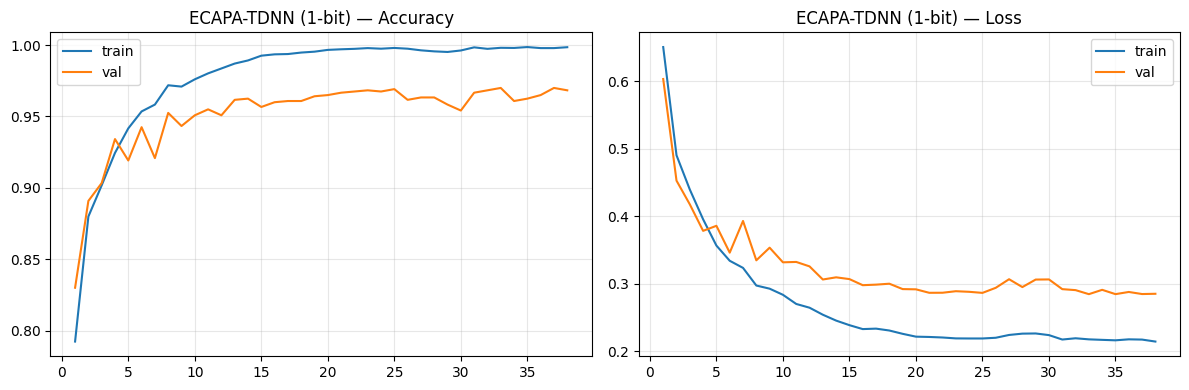

In [24]:
# ============================================================
# [1-bit] 7. Training curves
# ============================================================
hist_df_1 = plot_history(history_1, "ECAPA-TDNN (1-bit)")


ECAPA-TDNN (1-bit) — Test Set Performance
Accuracy   : 0.9617
Precision  : 0.9619
Recall     : 0.9617
F1 (macro) : 0.9617
ROC-AUC    : 0.9952
EER        : 0.0231

              precision    recall  f1-score   support

     Command     0.9417    0.9700    0.9557       300
Conversation     0.9729    0.9567    0.9647       300
     Numeric     1.0000    0.9933    0.9967       300
        Read     0.9329    0.9267    0.9298       300

    accuracy                         0.9617      1200
   macro avg     0.9619    0.9617    0.9617      1200
weighted avg     0.9619    0.9617    0.9617      1200



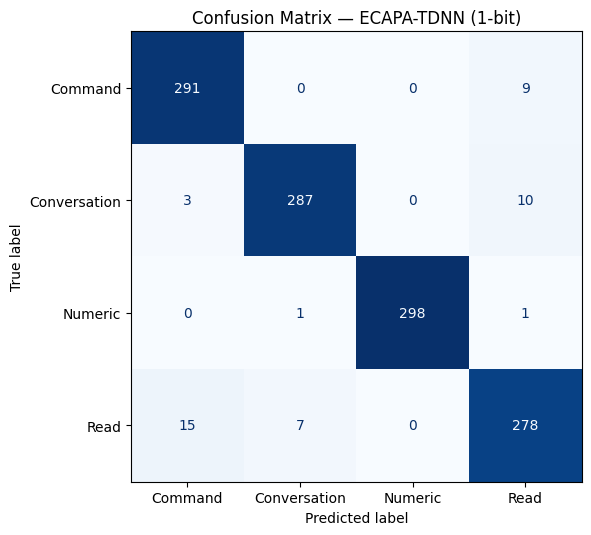

In [25]:
# ============================================================
# [1-bit] 8. Test evaluation (full report)
# ============================================================
model_1bit.load_state_dict(best_state_1)  # ensure best checkpoint (not last epoch) is evaluated
report_1bit = full_test_report(model_1bit, test_loader_1, tag="ECAPA-TDNN (1-bit)")


In [26]:
# ============================================================
# [1-bit] 9. MFCC baseline
# ============================================================
baseline_1bit = run_mfcc_baseline(X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1, tag="1-bit")


[1-bit] MFCC + LogisticRegression baseline — Test Acc: 0.8258 | Macro-F1: 0.8252


---
# Final comparison — 16-bit vs 1-bit
---

In [27]:
# ============================================================
# Comparison — bootstrap CI + McNemar test + results table
# ============================================================
def bootstrap_ci_paired(labels, preds, metric_fn, n_boot=2000, seed=0):
    rng = np.random.RandomState(seed)
    n = len(labels)
    stats = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        stats.append(metric_fn(labels[idx], preds[idx]))
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return float(np.mean(stats)), float(lo), float(hi)


def mcnemar_test(labels, preds_a, preds_b):
    correct_a = (preds_a == labels)
    correct_b = (preds_b == labels)
    n01 = int(np.sum(correct_a & ~correct_b))
    n10 = int(np.sum(~correct_a & correct_b))
    if n01 + n10 == 0:
        return 1.0
    stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    return 1 - chi2.cdf(stat, df=1)


acc_ci_16 = bootstrap_ci_paired(report_16bit["labels"], report_16bit["preds"], accuracy_score)
acc_ci_1 = bootstrap_ci_paired(report_1bit["labels"], report_1bit["preds"], accuracy_score)

print(f"ECAPA-TDNN 16-bit test accuracy 95% bootstrap CI: mean={acc_ci_16[0]:.4f} [{acc_ci_16[1]:.4f}, {acc_ci_16[2]:.4f}]")
print(f"ECAPA-TDNN 1-bit  test accuracy 95% bootstrap CI: mean={acc_ci_1[0]:.4f} [{acc_ci_1[1]:.4f}, {acc_ci_1[2]:.4f}]")

if len(report_16bit["labels"]) == len(report_1bit["labels"]):
    p_val = mcnemar_test(report_16bit["labels"], report_16bit["preds"], report_1bit["preds"])
    print(f"McNemar test (ECAPA-TDNN 16-bit vs 1-bit), paired on the same test items: p = {p_val:.4f}")
else:
    print("Test sets have different sizes/orderings — McNemar's test needs paired predictions "
          "on the SAME items, so it is skipped here. Re-derive matched test sets if you need this.")

results_table = pd.DataFrame([
    {"condition": "16-bit", "model": "ECAPA-TDNN (from scratch)", "accuracy": report_16bit["accuracy"],
     "precision": report_16bit["precision"], "recall": report_16bit["recall"],
     "f1_macro": report_16bit["f1_macro"], "roc_auc": report_16bit["roc_auc"], "eer": report_16bit["eer"]},
    {"condition": "16-bit", "model": "MFCC + LogReg", "accuracy": baseline_16bit["accuracy"],
     "precision": float("nan"), "recall": float("nan"),
     "f1_macro": baseline_16bit["macro_f1"], "roc_auc": float("nan"), "eer": float("nan")},
    {"condition": "1-bit", "model": "ECAPA-TDNN (from scratch)", "accuracy": report_1bit["accuracy"],
     "precision": report_1bit["precision"], "recall": report_1bit["recall"],
     "f1_macro": report_1bit["f1_macro"], "roc_auc": report_1bit["roc_auc"], "eer": report_1bit["eer"]},
    {"condition": "1-bit", "model": "MFCC + LogReg", "accuracy": baseline_1bit["accuracy"],
     "precision": float("nan"), "recall": float("nan"),
     "f1_macro": baseline_1bit["macro_f1"], "roc_auc": float("nan"), "eer": float("nan")},
])
print(results_table.to_string(index=False))
results_table.to_csv(os.path.join(OUT_DIR, "ecapa_results_table.csv"), index=False)


ECAPA-TDNN 16-bit test accuracy 95% bootstrap CI: mean=0.9942 [0.9900, 0.9983]
ECAPA-TDNN 1-bit  test accuracy 95% bootstrap CI: mean=0.9615 [0.9500, 0.9717]
McNemar test (ECAPA-TDNN 16-bit vs 1-bit), paired on the same test items: p = 0.0000
condition                     model  accuracy  precision   recall  f1_macro  roc_auc      eer
   16-bit ECAPA-TDNN (from scratch)  0.994167   0.994197 0.994167  0.994172 0.999835 0.003889
   16-bit             MFCC + LogReg  0.904167        NaN      NaN  0.903917      NaN      NaN
    1-bit ECAPA-TDNN (from scratch)  0.961667   0.961879 0.961667  0.961698 0.995213 0.023056
    1-bit             MFCC + LogReg  0.825833        NaN      NaN  0.825150      NaN      NaN


In [28]:
# ============================================================
# Optional — bring in the other backbones' numbers for a full comparison
# ============================================================
# If you ran the companion Wav2Vec2 / HuBERT / WavLM notebooks in the same session
# (or reload their saved `results_table` / `report_*` objects), you can compare all
# four backbones directly:
#
# w2v2_16, w2v2_1   = ...  # report_16bit['accuracy'], report_1bit['accuracy'] from Wav2Vec2
# hubert_16, hubert_1 = ...  # same, from HuBERT
# wavlm_16, wavlm_1 = ...  # same, from WavLM
#
# print(f"ECAPA-TDNN 16-bit acc: {report_16bit['accuracy']:.4f} | 1-bit acc: {report_1bit['accuracy']:.4f}")
#
# For a rigorous claim, run McNemar's test on each pair of backbones' predictions on
# the SAME held-out test items, and report bootstrap CIs for all of them rather than
# comparing point estimates informally.
#
# For reference, a PREVIOUSLY REPORTED ECAPA-TDNN run (not reproduced by this specific
# execution — treat as prior work, not as this run's result) gave:
#   Metric      16-bit   1-bit
#   Accuracy    0.9600   0.9417
#   Precision   0.9608   0.9414
#   Recall      0.9600   0.9417
#   F1-score    0.9600   0.9415
# Whatever `results_table` shows above from THIS run is the number to actually report;
# use the row above only as a sanity-check reference point, not a target to reach.


## Reporting checklist

- [ ] This notebook runs a **single seed** per condition by default (`SEED = 42`) for
      clarity. For a publishable claim, rerun both PART A and PART B with 2–4 more
      seed values and report **mean ± std**, not one run.
- [ ] Confirm the leakage check found 0 duplicates in both conditions before trusting
      any test number.
- [ ] Report the MFCC baseline alongside ECAPA-TDNN so the architecture's actual gain
      over a simple feature+LogReg pipeline is quantified, not assumed.
- [ ] If McNemar's `p > 0.05`, say the 16-bit vs 1-bit difference is not statistically
      distinguishable at this sample size rather than claiming a difference.
- [ ] If 1-bit underperforms substantially, treat that as a genuine robustness finding
      (the log-Mel front-end's FFT-based analysis is sensitive to the noise-shaping
      characteristics of PDM-style 1-bit quantization), not something to tune away.
- [ ] ECAPA-TDNN here is trained **from scratch**, unlike the fine-tuned SSL backbones
      in the companion notebooks — a higher (or lower) accuracy than those notebooks is
      not automatically an apples-to-apples "architecture X beats architecture Y" claim
      unless you also control for training-data size, epochs, and compute budget.
- [ ] Consider also reporting the paper-faithful **AAM-Softmax** variant
      (`USE_AAM_SOFTMAX = True`, using the `AAMSoftmax` class already defined above) as
      an ablation, since the original ECAPA-TDNN paper's results are obtained with that
      loss rather than plain cross-entropy.
- [ ] For a genuine cross-backbone paper claim (ECAPA-TDNN vs Wav2Vec2 vs HuBERT vs
      WavLM), evaluate all four on the **exact same test split and seeds**, then report
      paired statistics (McNemar / a paired bootstrap on the accuracy difference), not
      four separately-run numbers compared informally.
- [ ] Do not edit hyperparameters after seeing the test-set number in order to move it
      toward a previously reported figure — tune only against the validation set, and
      touch the test set exactly once per configuration you report.
